In [96]:
# Laplacian + circularity 기반 void edge 탐지 함수
def detect_voids_via_laplacian(patch, min_area=1, min_circularity=0.6, lap_thresh=20):
    blurred = cv2.GaussianBlur(patch, (5, 5), 0)
    laplacian = cv2.Laplacian(blurred, ddepth=cv2.CV_64F)
    abs_laplacian = np.uint8(np.absolute(laplacian))
    _, edge_bin = cv2.threshold(abs_laplacian, lap_thresh, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(edge_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_voids = []
    void_area = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        circularity = 4 * math.pi * area / (perimeter ** 2)
        if circularity >= min_circularity:
            valid_voids.append(cnt)
            void_area += area

    patch_area = patch.shape[0] * patch.shape[1]
    void_ratio = void_area / patch_area

    vis = cv2.cvtColor(patch, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(vis, valid_voids, -1, (255, 0, 0), 1)

    return vis, void_ratio, edge_bin

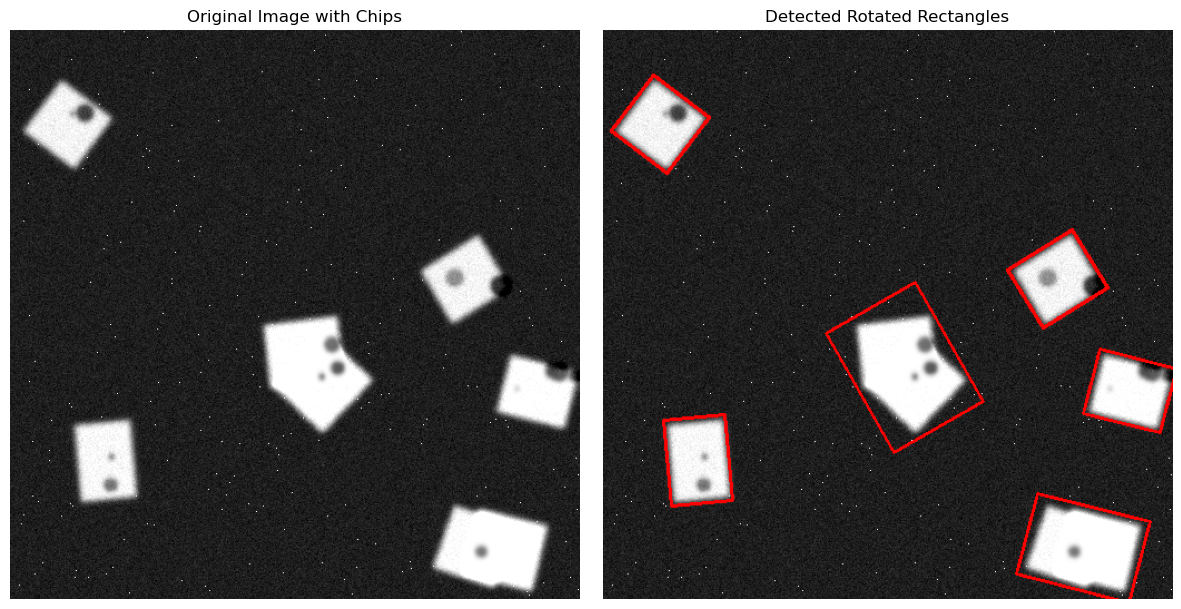

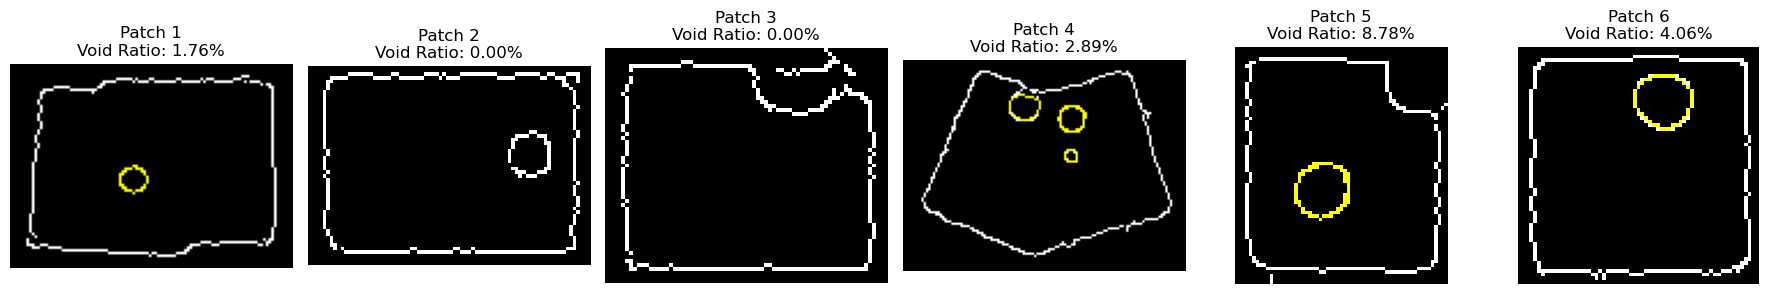

In [199]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# 흐릿하고 회전된 밝은 사각형을 가진 테스트 이미지 생성
def generate_advanced_fuzzy_rectangle_image(width=512, height=512, num_rects=7,
                                            brightness_range=(180, 255), size_range=(20, 100)):
    img = np.random.normal(loc=30, scale=10, size=(height, width)).astype(np.uint8)

    for _ in range(num_rects):
        w = np.random.randint(size_range[0], size_range[1])
        h = np.random.randint(size_range[0], size_range[1])
        angle = np.random.uniform(0, 180)
        brightness = np.random.randint(brightness_range[0], brightness_range[1])

        center = (np.random.randint(w//2, width-w//2),
                  np.random.randint(h//2, height-h//2))
        rect = (np.array(center, dtype=np.float32), (float(w), float(h)), float(angle))
        box = cv2.boxPoints(rect).astype(np.int32)

        mask = np.zeros_like(img)
        cv2.fillConvexPoly(mask, box, brightness)
        mask = cv2.GaussianBlur(mask, (15, 15), 0)
        img = cv2.add(img, mask)

    return np.clip(img, 0, 255).astype(np.uint8)

# void를 특정 patch 경계 내부에만 생성하도록 수정한 버전
def generate_chip_with_targeted_voids(width=512, height=512, num_rects=7, num_voids=15,
                                       brightness_range=(180, 255), size_range=(30, 100),
                                       void_radius_range=(4, 12), void_darkness_range=(0, 40)):
    img = np.random.normal(loc=30, scale=10, size=(height, width)).astype(np.uint8)
    patch_boxes = []  # void 위치를 위한 박스 정보 저장

    # 1. 밝은 칩(회전 사각형) 생성 및 마스크 기록
    for _ in range(num_rects):
        w = np.random.randint(size_range[0], size_range[1])
        h = np.random.randint(size_range[0], size_range[1])
        angle = np.random.uniform(0, 180)
        brightness = np.random.randint(brightness_range[0], brightness_range[1])

        center = (np.random.randint(w//2, width-w//2),
                  np.random.randint(h//2, height-h//2))
        rect = (np.array(center, dtype=np.float32), (float(w), float(h)), float(angle))
        box = cv2.boxPoints(rect).astype(np.int32)
        patch_boxes.append(box)

        # 사각형 이미지 생성
        mask = np.zeros_like(img)
        cv2.fillConvexPoly(mask, box, brightness)
        mask = cv2.GaussianBlur(mask, (15, 15), 0)
        img = cv2.add(img, mask)

    # 2. void는 각 사각형 내부에만 생성
    void_layer = np.zeros_like(img, dtype=np.uint8)

    for _ in range(num_voids):
        box = patch_boxes[np.random.randint(0, len(patch_boxes))]  # 랜덤 patch 선택

        # 박스 내부에 포인트 샘플링
        while True:
            rx = np.random.randint(min(box[:, 0]), max(box[:, 0]))
            ry = np.random.randint(min(box[:, 1]), max(box[:, 1]))
            if cv2.pointPolygonTest(box, (rx, ry), measureDist=False) >= 0:
                break

        radius = np.random.randint(void_radius_range[0], void_radius_range[1])
        darkness = np.random.randint(void_darkness_range[0], void_darkness_range[1])
        cv2.circle(void_layer, (rx, ry), radius, darkness, -1)

        # 물결무늬 추가
        for angle in np.linspace(0, 2*np.pi, 20):
            vx = int(rx + radius * 0.9 * np.cos(angle))
            vy = int(ry + radius * 0.9 * np.sin(angle) + 2 * np.sin(6 * angle))
            if 0 <= vx < width and 0 <= vy < height:
                void_layer[vy, vx] = min(void_layer[vy, vx] + darkness, 255)

    # 블러 후 이미지에 반영
    void_layer = cv2.GaussianBlur(void_layer, (11, 11), 0)
    img = cv2.subtract(img, void_layer)

    return np.clip(img, 0, 255).astype(np.uint8)


# 회전 사각형 검출 및 추출
def extract_rotated_bright_rectangles(img, brightness_thresh=200, area_thresh=500):
    blurred = cv2.GaussianBlur(img, (7, 7), 0)
    _, binary = cv2.threshold(blurred, brightness_thresh, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    rotated_patches = []

    for cnt in contours:
        if cv2.contourArea(cnt) < area_thresh:
            continue

        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect).astype(np.int32)
        cv2.drawContours(result_img, [box], 0, (0, 0, 255), 2)

        width, height = map(int, rect[1])
        if width == 0 or height == 0:
            continue

        src_pts = box.astype("float32")
        dst_pts = np.array([[0, height-1],
                            [0, 0],
                            [width-1, 0],
                            [width-1, height-1]], dtype="float32")

        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        warped = cv2.warpPerspective(img, M, (width, height))
        rotated_patches.append(warped)

    return result_img, rotated_patches

# 회전된 밝은 사각형(칩) 검출 + 마진 포함 패치 추출
def extract_rotated_bright_rectangles_with_margin(img, brightness_thresh=200, area_thresh=500, margin_ratio=0.1):
    blurred = cv2.GaussianBlur(img, (7, 7), 0)
    _, binary = cv2.threshold(blurred, brightness_thresh, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    rotated_patches = []

    h_img, w_img = img.shape[:2]

    for cnt in contours:
        if cv2.contourArea(cnt) < area_thresh:
            continue

        rect = cv2.minAreaRect(cnt)
        width, height = rect[1]
        angle = rect[2]

        # 마진 적용
        margin_w = width * margin_ratio
        margin_h = height * margin_ratio
        new_size = (width + 2 * margin_w, height + 2 * margin_h)
        new_rect = (rect[0], new_size, angle)

        box = cv2.boxPoints(new_rect).astype(np.int32)
        cv2.drawContours(result_img, [box], 0, (0, 0, 255), 2)

        # 패치 추출
        W, H = map(int, new_size)
        if W == 0 or H == 0:
            continue

        src_pts = box.astype("float32")
        dst_pts = np.array([[0, H-1],
                            [0, 0],
                            [W-1, 0],
                            [W-1, H-1]], dtype="float32")

        M = cv2.getPerspectiveTransform(src_pts, dst_pts)
        warped = cv2.warpPerspective(img, M, (W, H))
        rotated_patches.append(warped)

    return result_img, rotated_patches

# 추출된 패치 저장 및 시각화
def visualize_and_save_patches(patches, output_dir="patches", max_show=10):
    os.makedirs(output_dir, exist_ok=True)

    num_show = min(len(patches), max_show)
    fig, axes = plt.subplots(1, num_show, figsize=(3 * num_show, 3))
    if num_show == 1:
        axes = [axes]

    for i in range(num_show):
        patch = patches[i]
        axes[i].imshow(patch, cmap='gray')
        axes[i].set_title(f'Patch {i+1}')
        axes[i].axis('off')

        filename = os.path.join(output_dir, f"patch_{i+1}.png")
        cv2.imwrite(filename, patch)

    plt.tight_layout()
    plt.show()
    
# circularity 필터 포함 void 검출 함수
def detect_and_visualize_voids_circularity(patch, void_thresh=80, min_void_area=0.001, min_circularity=0.9):
    blur = cv2.GaussianBlur(patch, (5, 5), 0)
    vis = cv2.cvtColor(patch, cv2.COLOR_GRAY2BGR)
    _, thresh = cv2.threshold(patch, void_thresh, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    void_area = 0
    valid_voids = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        cv2.drawContours(vis, cnt, -1, (0, 0, 255), 1)
        if area < min_void_area:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        circularity = 4 * math.pi * area / (perimeter ** 2)

        if circularity >= min_circularity:
            void_area += area
            valid_voids.append(cnt)

    patch_area = patch.shape[0] * patch.shape[1]
    void_ratio = void_area / patch_area

    
    cv2.drawContours(vis, valid_voids, -1, (0, 0, 255), 1)

    return vis, void_ratio


# 메인 실행
if __name__ == "__main__":

    # 1. 전체 이미지 생성 및 칩 추출
    composite_img = generate_chip_with_targeted_voids(
            brightness_range=(200, 250),
            size_range=(50, 70),
            void_darkness_range=(100,200),
            void_radius_range=(0.1,10),
            num_rects=8
        )
    detected_img, patches = extract_rotated_bright_rectangles_with_margin(composite_img)

    # 2. 패치별 void 분석
    patch_void_imgs = []
    patch_void_ratios = []



    for patch in patches:
        void_vis, void_ratio, void_edge = detect_voids_via_laplacian(patch)
        patch = cv2.GaussianBlur(patch, (5, 5), 0)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(10, 10))
        #patch = clahe.apply(patch)

        
        inverted = 255 - patch  # blob은 밝은 점으로 인식됨

        # 4. 시각화
        vis = cv2.cvtColor(patch, cv2.COLOR_GRAY2BGR)
        
        
        close_kernel_size = 5
        edges = cv2.Canny(inverted, 50, 200)  # Canny edge detection 사용
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel_size, close_kernel_size))
        closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)        # 3. contour 추출
        
        contours, _ = cv2.findContours(closed_edges, cv2.RETR_TREE , cv2.CHAIN_APPROX_SIMPLE)
        min_circularity = 0.5
        min_area = 0
        max_area = 1000
        valid_contours = []
        void_area = 0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if (area < min_area) or (area > max_area):
                continue
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0:
                continue
            circularity = 4 * math.pi * area / (perimeter ** 2)
            if circularity >= min_circularity:
                valid_contours.append(cnt)
                void_area += area

        patch_area = patch.shape[0] * patch.shape[1]
        void_ratio = void_area / patch_area

        # 시각화
        vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(vis, valid_contours, -1, (0, 255, 255), 1)


        patch_void_imgs.append(vis)
        patch_void_ratios.append(void_ratio)

    # 3. 전체 이미지 및 칩 경계 결과 시각화
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 6))
    axes1[0].imshow(composite_img, cmap='gray')
    axes1[0].set_title("Original Image with Chips")
    axes1[0].axis('off')

    axes1[1].imshow(cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB))
    axes1[1].set_title("Detected Rotated Rectangles")
    axes1[1].axis('off')
    plt.tight_layout()
    plt.show()

    # 4. 각 패치별 void 경계 시각화 결과
    num_to_show = min(6, len(patch_void_imgs))
    fig2, axes2 = plt.subplots(1, num_to_show, figsize=(3 * num_to_show, 3))
    if num_to_show == 1:
        axes2 = [axes2]

    for i in range(num_to_show):
        axes2[i].imshow(cv2.cvtColor(patch_void_imgs[i], cv2.COLOR_BGR2RGB))
        ratio = patch_void_ratios[i]
        axes2[i].set_title(f'Patch {i+1}\nVoid Ratio: {ratio:.2%}')
        axes2[i].axis('off')

    plt.tight_layout()
    plt.show()
